# College Student Placement

In [1]:
library(data.table)
library(tidyverse)
library(rpart)
library(rpart.plot)
library(randomForest)
library(caret)


Attaching package: 'data.table'


The following object is masked from 'package:base':

    %notin%


── Attaching core tidyverse packages ──────────────────────────────────────────────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.2.1     ✔ readr     2.2.0
✔ forcats   1.0.1     ✔ stringr   1.6.0
✔ ggplot2   4.0.3     ✔ tibble    3.3.1
✔ lubridate 1.9.5     ✔ tidyr     1.3.2
✔ purrr     1.2.2     
── Conflicts ────────────────────────────────────────────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::between()     masks data.table::between()
✖ dplyr::filter()      masks stats::filter()
✖ dplyr::first()       masks data.table::first()
✖ lubridate::hour()    masks data.table::hour()
✖ lubridate::isoweek() masks data.table::isoweek()
✖ lubridate::isoyear() masks data.table::isoyear()
✖ dplyr::lag()         masks stats::lag()
✖ dplyr::last()        masks data.table::last()
✖ lubridate::mday()    masks data.table::mday()
✖ lubridate::minute()  masks data.table:

## <div class="alert alert-block alert-success"> Section 1: Business Understanding and Data Exploration </div>

### Clean the data set

In [2]:
library(dplyr)
library(stringr)
library(readr)

df <- read_csv("data/college_admissions.csv")

colnames(df) <- colnames(df) %>%
  tolower() %>%
  str_replace_all("[\\s-]+", "_")

df <- df %>%
  mutate(across(where(is.character), ~ na_if(.x, "-1")))

clean_list_string <- function(column) {
  column %>%
    str_remove_all("[\\[\\]'*]") %>%
    str_replace_all(",\\s*", ", ") %>%
    str_trim()
}

count_elements <- function(column_clean) {
  if_else(
    column_clean == "" | is.na(column_clean), 
    0L, 
    as.integer(str_count(column_clean, ",") + 1)
  )
}

df <- df %>%
  mutate(
    acceptances_clean = clean_list_string(acceptances),
    waitlists_clean   = clean_list_string(waitlists),
    rejections_clean  = clean_list_string(rejections),
    num_acceptances   = count_elements(acceptances_clean),
    num_waitlists     = count_elements(waitlists_clean),
    num_rejections    = count_elements(rejections_clean)
  )

categorical_cols <- c("gender", "race", "residence", "income", "school_type", "hooks", "major")
df <- df %>%
  mutate(across(all_of(categorical_cols), as.factor))

summary(df)
write_csv(df, "data/college_admissions_cleaned.csv")

Rows: 1484 Columns: 14
── Column specification ────────────────────────────────────────────────────────────────────────────────────────────────
Delimiter: ","
chr (11): Gender, Race, Residence, Income, School Type, Hooks, Major, Accept...
dbl  (3): SAT, EC-AWARDS, ESSAY-LOR-INTERVIEW

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


   gender          race       residence      income           school_type 
 F    :523   ASIAN   :844   CA     :345   High  :413   PUBLIC       :872  
 M    :898   WHITE   :417   NY     : 95   Low   :916   PRIVATE      :259  
 NB   : 31   BLACK   :116   IN     : 90   Middle: 88   CHARTER      : 22  
 OTHER: 18   HISPANIC: 65   TX     : 86   NAs   : 67   INTERNATIONAL: 14  
 T    : 14   ARAB    :  7   OR     : 85                MAGNET       : 12  
             (Other) :  6   (Other):672                (Other)      : 16  
             NAs     : 29   NAs    :111                NAs          :289  
       hooks           major          sat         ec_awards     
 FIRST-GEN: 146   CS      :650   Min.   :1000   Min.   :-1.000  
 LEGACY   : 139   ENG     :217   1st Qu.:1450   1st Qu.: 5.000  
 LGBT     :  20   BIO     :117   Median :1520   Median : 6.500  
 NONE     :1003   BUSINESS: 94   Mean   :1490   Mean   : 5.881  
 URM      : 176   POLISCI : 68   3rd Qu.:1550   3rd Qu.: 7.500  
          

In [3]:
college <- fread("data/college_admissions_cleaned.csv")
college <- college %>%
  select(
    gender, race, residence, income, school_type, hooks, major, sat, 
    ec_awards, essay_lor_interview, acceptances_clean, waitlists_clean, 
    rejections_clean, num_acceptances, num_waitlists, num_rejections
  )
head(college)

gender,race,residence,income,school_type,hooks,major,sat,ec_awards,essay_lor_interview,acceptances_clean,waitlists_clean,rejections_clean,num_acceptances,num_waitlists,num_rejections
<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<int>,<dbl>,<dbl>,<chr>,<chr>,<chr>,<int>,<int>,<int>
M,ASIAN,MI,Low,NA,NONE,CS,1440,2.0,4.5,PURDUE,"GEORGIA TECH, UMICH","UIUC, NORTHEASTERN",1,2,2
OTHER,ASIAN,IN,High,NA,NONE,CS,1390,5.5,4.5,STANFORD,,CALTECH,1,0,1
F,ASIAN,MA,High,PUBLIC,NONE,NEUROSCIENCE,1580,7.5,7.5,"UCLA, HARVARD, YALE, COLUMBIA, DUKE, NYU, UMICH, UNC CHAPEL HILL, UVA",UPENN,"STANFORD, COLUMBIA",9,1,2
M,WHITE,IN,Low,NA,URM,CS,1580,5.5,1.5,"GEORGIA TECH, UT-AUSTIN, ARIZONA STATE, UCI","HARVARD, UCHICAGO","UCLA, NORTHWESTERN, UMICH, EMORY, USC, HARVEY MUDD, UNC CHAPEL HILL, UVA",4,2,8
F,ASIAN,OR,Middle,PUBLIC,NONE,CS,1580,7.5,4.7,"CORNELL, RUTGERS",,CORNELL,2,0,1
F,WHITE,NY,Low,PUBLIC,NONE,CS,1550,8.5,8.0,MIT,,,1,0,0


### Prepare Data

In [4]:
library(dplyr)
library(tidyr)

college <- college %>% 
  mutate(student_id = row_number())

apps_accepted <- college %>%
  select(
    student_id, gender, race, residence, income, school_type, hooks, 
    major, sat, ec_awards, essay_lor_interview, acceptances_clean
  ) %>%
  separate_rows(acceptances_clean, sep = ", ") %>%
  filter(acceptances_clean != "") %>%
  rename(target_college = acceptances_clean) %>%
  mutate(accepted = 1)

apps_rejected <- college %>%
  select(
    student_id, gender, race, residence, income, school_type, hooks, 
    major, sat, ec_awards, essay_lor_interview, rejections_clean
  ) %>%
  separate_rows(rejections_clean, sep = ", ") %>%
  filter(rejections_clean != "") %>%
  rename(target_college = rejections_clean) %>%
  mutate(accepted = 0)

college_prepared <- bind_rows(apps_accepted, apps_rejected) %>%
  mutate(target_college = as.factor(target_college))

college_prepared <- na.omit(college_prepared)

head(college_prepared)

student_id,gender,race,residence,income,school_type,hooks,major,sat,ec_awards,essay_lor_interview,target_college,accepted
<int>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<int>,<dbl>,<dbl>,<fct>,<dbl>
3,F,ASIAN,MA,High,PUBLIC,NONE,NEUROSCIENCE,1580,7.5,7.5,UCLA,1
3,F,ASIAN,MA,High,PUBLIC,NONE,NEUROSCIENCE,1580,7.5,7.5,HARVARD,1
3,F,ASIAN,MA,High,PUBLIC,NONE,NEUROSCIENCE,1580,7.5,7.5,YALE,1
3,F,ASIAN,MA,High,PUBLIC,NONE,NEUROSCIENCE,1580,7.5,7.5,COLUMBIA,1
3,F,ASIAN,MA,High,PUBLIC,NONE,NEUROSCIENCE,1580,7.5,7.5,DUKE,1
3,F,ASIAN,MA,High,PUBLIC,NONE,NEUROSCIENCE,1580,7.5,7.5,NYU,1


In [5]:
fwrite(college_prepared, "data/college_admission_final.csv")

### Summary

In [6]:
dim(college_prepared)
names(college_prepared)
str(college_prepared)
summary(college_prepared)

[1] 7907   13

[1] "student_id"          "gender"              "race"               
 [4] "residence"           "income"              "school_type"        
 [7] "hooks"               "major"               "sat"                
[10] "ec_awards"           "essay_lor_interview" "target_college"     
[13] "accepted"

tibble [7,907 × 13] (S3: tbl_df/tbl/data.frame)
 $ student_id         : int [1:7907] 3 3 3 3 3 3 3 3 3 5 ...
 $ gender             : chr [1:7907] "F" "F" "F" "F" ...
 $ race               : chr [1:7907] "ASIAN" "ASIAN" "ASIAN" "ASIAN" ...
 $ residence          : chr [1:7907] "MA" "MA" "MA" "MA" ...
 $ income             : chr [1:7907] "High" "High" "High" "High" ...
 $ school_type        : chr [1:7907] "PUBLIC" "PUBLIC" "PUBLIC" "PUBLIC" ...
 $ hooks              : chr [1:7907] "NONE" "NONE" "NONE" "NONE" ...
 $ major              : chr [1:7907] "NEUROSCIENCE" "NEUROSCIENCE" "NEUROSCIENCE" "NEUROSCIENCE" ...
 $ sat                : int [1:7907] 1580 1580 1580 1580 1580 1580 1580 1580 1580 1580 ...
 $ ec_awards          : num [1:7907] 7.5 7.5 7.5 7.5 7.5 7.5 7.5 7.5 7.5 7.5 ...
 $ essay_lor_interview: num [1:7907] 7.5 7.5 7.5 7.5 7.5 7.5 7.5 7.5 7.5 4.7 ...
 $ target_college     : Factor w/ 58 levels "ARIZONA STATE",..: 39 18 58 11 14 24 46 47 52 12 ...
 $ accepted           : num [1:79

   student_id           gender            race          residence   
 Min.   :   3.0   Length   :7907   Length   :7907   Length   :7907  
 1st Qu.: 390.0   N.unique :   5   N.unique :   6   N.unique :  32  
 Median : 756.0   N.blank  :   0   N.blank  :   0   N.blank  :   0  
 Mean   : 738.5   Min.nchar:   1   Min.nchar:   4   Min.nchar:   2  
 3rd Qu.:1065.0   Max.nchar:   5   Max.nchar:   8   Max.nchar:  13  
 Max.   :1484.0                                                     
                                                                    
       income        school_type         hooks            major     
 Length   :7907   Length   :7907   Length   :7907   Length   :7907  
 N.unique :   3   N.unique :   7   N.unique :   5   N.unique :  26  
 N.blank  :   0   N.blank  :   0   N.blank  :   0   N.blank  :   0  
 Min.nchar:   3   Min.nchar:   5   Min.nchar:   3   Min.nchar:   2  
 Max.nchar:   6   Max.nchar:  13   Max.nchar:   9   Max.nchar:  23  
                                  

### Missing Values

In [7]:
missing_summary <- data.table(
  variable = names(college_prepared),
  missing_count = colSums(is.na(college_prepared))
)

missing_summary[, missing_percent := round(100 * missing_count / nrow(college_prepared), 2)]

missing_summary[order(-missing_count)]

variable,missing_count,missing_percent
<chr>,<dbl>,<dbl>
student_id,0,0
gender,0,0
race,0,0
residence,0,0
income,0,0
school_type,0,0
hooks,0,0
major,0,0
sat,0,0


### Convert chr columns to Factors

In [8]:
library(dplyr)
library(forcats)

college_prepared <- college_prepared %>%
  mutate(gender = fct_collapse(gender,
    LGBTQ = c("NB", "T", "OTHER"),
    M = "M",
    F = "F"
  ))

str(college_prepared)

tibble [7,907 × 13] (S3: tbl_df/tbl/data.frame)
 $ student_id         : int [1:7907] 3 3 3 3 3 3 3 3 3 5 ...
 $ gender             : Factor w/ 3 levels "F","M","LGBTQ": 1 1 1 1 1 1 1 1 1 1 ...
 $ race               : chr [1:7907] "ASIAN" "ASIAN" "ASIAN" "ASIAN" ...
 $ residence          : chr [1:7907] "MA" "MA" "MA" "MA" ...
 $ income             : chr [1:7907] "High" "High" "High" "High" ...
 $ school_type        : chr [1:7907] "PUBLIC" "PUBLIC" "PUBLIC" "PUBLIC" ...
 $ hooks              : chr [1:7907] "NONE" "NONE" "NONE" "NONE" ...
 $ major              : chr [1:7907] "NEUROSCIENCE" "NEUROSCIENCE" "NEUROSCIENCE" "NEUROSCIENCE" ...
 $ sat                : int [1:7907] 1580 1580 1580 1580 1580 1580 1580 1580 1580 1580 ...
 $ ec_awards          : num [1:7907] 7.5 7.5 7.5 7.5 7.5 7.5 7.5 7.5 7.5 7.5 ...
 $ essay_lor_interview: num [1:7907] 7.5 7.5 7.5 7.5 7.5 7.5 7.5 7.5 7.5 4.7 ...
 $ target_college     : Factor w/ 58 levels "ARIZONA STATE",..: 39 18 58 11 14 24 46 47 52 12 ...
 $ acc

In [9]:
setDT(college_prepared)
new <- fread("data/college_admission_final.csv", select = "accepted")[[1]]
college_prepared[,accepted := new,]
college_prepared[, accepted := factor(
  accepted,
  levels = c(0, 1),
  labels = c("No", "Yes")
)]
college_prepared$major <- as.factor(college_prepared$major)
college_prepared$race <- as.factor(college_prepared$race)
college_prepared$residence <- as.factor(college_prepared$residence)
college_prepared$income <- as.factor(college_prepared$income)
college_prepared$school_type <- as.factor(college_prepared$school_type)
college_prepared$hooks <- as.factor(college_prepared$hooks)
college_prepared$gender <- as.factor(college_prepared$gender)
college_prepared$target_college <- as.factor(college_prepared$target_college)

str(college_prepared)



Classes 'data.table' and 'data.frame':	7907 obs. of  13 variables:
 $ student_id         : int  3 3 3 3 3 3 3 3 3 5 ...
 $ gender             : Factor w/ 3 levels "F","M","LGBTQ": 1 1 1 1 1 1 1 1 1 1 ...
 $ race               : Factor w/ 6 levels "ARAB","ASIAN",..: 2 2 2 2 2 2 2 2 2 2 ...
 $ residence          : Factor w/ 32 levels "AL","AZ","CA",..: 14 14 14 14 14 14 14 14 14 24 ...
 $ income             : Factor w/ 3 levels "High","Low","Middle": 1 1 1 1 1 1 1 1 1 3 ...
 $ school_type        : Factor w/ 7 levels "CHARTER","INTERNATIONAL",..: 6 6 6 6 6 6 6 6 6 6 ...
 $ hooks              : Factor w/ 5 levels "FIRST-GEN","LEGACY",..: 4 4 4 4 4 4 4 4 4 4 ...
 $ major              : Factor w/ 26 levels "ARTS","BIO","BUSINESS",..: 18 18 18 18 18 18 18 18 18 5 ...
 $ sat                : int  1580 1580 1580 1580 1580 1580 1580 1580 1580 1580 ...
 $ ec_awards          : num  7.5 7.5 7.5 7.5 7.5 7.5 7.5 7.5 7.5 7.5 ...
 $ essay_lor_interview: num  7.5 7.5 7.5 7.5 7.5 7.5 7.5 7.5 7.5 4.7 ...


### Acceptance Rate

In [10]:
acceptance_rate <- college_prepared[ , .N, by = accepted]

acceptance_rate[, percent := round(100 * N / sum(N), 1)]

acceptance_rate

accepted,N,percent
<fct>,<int>,<dbl>
Yes,3160,40
No,4747,60


## <div class="alert alert-block alert-success"> Section 2: Train-Test Split </div>


In [53]:
set.seed(123)
train_index <- createDataPartition(college_prepared$accepted, p = 0.8, list = FALSE)
train <- college_prepared[train_index, ]
test  <- college_prepared[-train_index, ]
dim(train)
dim(test)

[1] 6326   13

[1] 1581   13

### Baseline Model

In [12]:
table(train$accepted)

baseline_class <- names(which.max(table(train$accepted)))

baseline_pred <- factor(
  rep(baseline_class, nrow(test)),
  levels = levels(test$accepted)
)

mean(baseline_pred == test$accepted)


  No  Yes 
3798 2528 

[1] 0.600253

## <div class="alert alert-block alert-success"> Section 3: Random Forest Model </div>

In [13]:
college_prepared$gender[is.na(college_prepared$gender)] <- "LGBTQ"
college_prepared$gender

[1] F     F     F     F     F     F     F     F     F     F     F     F    
  [13] F     F     F     F     LGBTQ LGBTQ LGBTQ M     M     M     M     M    
  [25] F     F     M     M     M     M     M     F     F     F     M     M    
  [37] F     F     F     F     F     F     F     F     F     F     F     F    
  [49] F     F     M     M     F     F     F     F     F     F     F     F    
  [61] F     F     F     F     F     M     M     M     M     M     M     M    
  [73] M     M     M     M     M     M     M     M     M     F     F     F    
  [85] F     F     F     F     M     M     M     M     M     M     M     M    
  [97] M     M     F     F     F     F     F     F     F     F     F     F    
 [109] F     M     M     M     M     M     M     M     M     M     M     M    
 [121] M     M     F     F     F     M     M     M     M     M     M     M    
 [133] M     M     M     M     M     F     F     M     M     M     M     M    
 [145] M     M     M     M     M     M     M     M     M     M     M     M    
 [157] M     M     M     M     M     M     F     F     F     F     F     F    
 [169] M     M     M     M     M     M     M     M     M     M     M     M    
 [181] F     M     LGBTQ LGBTQ M     M     M     M     M     M     M     M    
 [193] F     F     M     M     M     M     M     M     M     M     M     M    
 [205] F     F     F     F     F     F     M     M     M     M     M     F    
 [217] M     M     M     M     M     M     M     M     M     M     M     M    
 [229] M     M     M     F     F     F     F     F     M     M     M     M    
 [241] M     M     M     M     M     M     M     M     M     M     M     M    
 [253] M     M     M     M     M     M     F     F     F     F     F     F    
 [265] F     F     F     F     M     M     M     F     F     F     M     M    
 [277] M     M     M     M     M     M     M     M     M     F     F     F    
 [289] F     F     F     F     F     F     F     M     M     M     M     M    
 [301] M     M     M     M     M     F     F     F     F     F     F     F    
 [313] F     F     F     F     M     M     M     M     M     M     M     M    
 [325] M     M     M     M     M     M     M     M     M     M     M     M    
 [337] M     M     M     M     M     M     M     M     M     M     M     M    
 [349] M     M     M     M     M     F     M     M     M     M     M     M    
 [361] M     M     M     M     M     M     M     M     M     M     M     M    
 [373] M     M     M     M     M     M     M     F     F     F     M     M    
 [385] M     M     M     M     M     M     M     M     M     M     M     M    
 [397] M     F     F     F     F     M     M     F     F     F     M     M    
 [409] M     M     M     M     M     M     M     F     F     F     F     F    
 [421] F     F     F     F     F     F     F     F     F     F     F     F    
 [433] F     F     F     F     F     M     M     M     M     M     M     F    
 [445] F     F     F     F     F     F     F     F     F     M     M     M    
 [457] M     M     M     M     F     F     F     F     F     F     F     F    
 [469] M     M     M     M     M     F     F     F     F     F     F     F    
 [481] F     F     F     F     F     F     F     F     F     F     F     F    
 [493] F     F     M     M     M     F     F     F     M     M     M     M    
 [505] M     F     F     F     F     F     F     F     F     F     LGBTQ M    
 [517] M     M     M     F     F     F     F     F     M     M     M     M    
 [529] M     M     M     M     M     M     M     M     M     M     M     M    
 [541] M     M     M     M     M     M     M     M     M     M     M     M    
 [553] M     M     M     M     M     F     F     F     F     F     F     F    
 [565] M     M     M     M     M     M     M     M     M     M     M     F    
 [577] F     F     F     F     F     F     F     M     M     M     M     M    
 [589] M     M     M     M     M     F     F     F     F     F     M     M    
 [601] F     F     M     M     M     M     M     M   

In [14]:
str(college_prepared)

Classes 'data.table' and 'data.frame':	7907 obs. of  13 variables:
 $ student_id         : int  3 3 3 3 3 3 3 3 3 5 ...
 $ gender             : Factor w/ 3 levels "F","M","LGBTQ": 1 1 1 1 1 1 1 1 1 1 ...
 $ race               : Factor w/ 6 levels "ARAB","ASIAN",..: 2 2 2 2 2 2 2 2 2 2 ...
 $ residence          : Factor w/ 32 levels "AL","AZ","CA",..: 14 14 14 14 14 14 14 14 14 24 ...
 $ income             : Factor w/ 3 levels "High","Low","Middle": 1 1 1 1 1 1 1 1 1 3 ...
 $ school_type        : Factor w/ 7 levels "CHARTER","INTERNATIONAL",..: 6 6 6 6 6 6 6 6 6 6 ...
 $ hooks              : Factor w/ 5 levels "FIRST-GEN","LEGACY",..: 4 4 4 4 4 4 4 4 4 4 ...
 $ major              : Factor w/ 26 levels "ARTS","BIO","BUSINESS",..: 18 18 18 18 18 18 18 18 18 5 ...
 $ sat                : int  1580 1580 1580 1580 1580 1580 1580 1580 1580 1580 ...
 $ ec_awards          : num  7.5 7.5 7.5 7.5 7.5 7.5 7.5 7.5 7.5 7.5 ...
 $ essay_lor_interview: num  7.5 7.5 7.5 7.5 7.5 7.5 7.5 7.5 7.5 4.7 ...


### Generate Random Forest

In [101]:
set.seed(123)

rf_model <- randomForest(
  accepted ~ gender + race + income + school_type + hooks + major + sat + ec_awards + essay_lor_interview,
  data = train,
  ntree = 300,
  importance = TRUE
)

rf_model


Call:
 randomForest(formula = accepted ~ gender + race + income + school_type +      hooks + major + sat + ec_awards + essay_lor_interview, data = train,      ntree = 300, importance = TRUE) 
               Type of random forest: classification
                     Number of trees: 300
No. of variables tried at each split: 3

        OOB estimate of  error rate: 33.18%
Confusion matrix:
      No  Yes class.error
No  3025  773   0.2035282
Yes 1326 1202   0.5245253

### Make Predictions

In [102]:
rf_pred <- predict(
  rf_model,
  newdata = test
)

head(rf_pred)

1   2   3   4   5   6 
 No Yes Yes Yes  No  No 
Levels: No Yes

### Confusion Matrix

In [103]:
confusionMatrix(
  rf_pred,
  test$accepted,
  positive = "Yes"
)

Confusion Matrix and Statistics

          Reference
Prediction  No Yes
       No  757 346
       Yes 192 286
                                          
               Accuracy : 0.6597          
                 95% CI : (0.6358, 0.6831)
    No Information Rate : 0.6003          
    P-Value [Acc > NIR] : 6.329e-07       
                                          
                  Kappa : 0.2608          
                                          
 Mcnemar's Test P-Value : 4.216e-11       
                                          
            Sensitivity : 0.4525          
            Specificity : 0.7977          
         Pos Pred Value : 0.5983          
         Neg Pred Value : 0.6863          
             Prevalence : 0.3997          
         Detection Rate : 0.1809          
   Detection Prevalence : 0.3023          
      Balanced Accuracy : 0.6251          
                                          
       'Positive' Class : Yes             
                              

### Accuracy

In [104]:
rf_accuracy <- round(mean(rf_pred == test$accepted),2)
rf_accuracy <- paste0(rf_accuracy * 100,"%")

rf_accuracy

[1] "66%"

## <div class="alert alert-block alert-success"> Section 4: Logistic Regression Model </div>

In [105]:
library(caret)

# 1. Set up the 10-fold cross-validation control
# 'classProbs = TRUE' ensures caret can compute probabilities for "No" and "Yes"
control <- trainControl(
  method = "cv", 
  number = 10, 
  classProbs = TRUE, 
  summaryFunction = defaultSummary
)

# 2. Train the Logistic Regression Model
set.seed(123) # For reproducibility across cross-validation folds
lr_model <- train(
  accepted ~ gender + race + income + school_type + hooks + major + sat + ec_awards + essay_lor_interview,
  data = train,
  method = "glm",
  family = "binomial",
  trControl = control
)


# 4. View detailed results (Accuracy and Kappa)
print(lr_model$results)


Warning message in predict.lm(object, newdata, se.fit, scale = 1, type = if (type == :
"prediction from rank-deficient fit; attr(*, "non-estim") has doubtful cases"
Warning message in predict.lm(object, newdata, se.fit, scale = 1, type = if (type == :
"prediction from rank-deficient fit; attr(*, "non-estim") has doubtful cases"


  parameter  Accuracy      Kappa AccuracySD    KappaSD
1      none 0.6116071 0.06944823 0.01438054 0.03665662


### Make Predictions

In [106]:
lr_pred <- predict(
  lr_model,
  newdata = test
)

confusionMatrix(
    lr_pred,
  test$accepted,
  positive = "Yes"
)

Warning message in predict.lm(object, newdata, se.fit, scale = 1, type = if (type == :
"prediction from rank-deficient fit; attr(*, "non-estim") has doubtful cases"


Confusion Matrix and Statistics

          Reference
Prediction  No Yes
       No  887 549
       Yes  62  83
                                         
               Accuracy : 0.6135         
                 95% CI : (0.589, 0.6376)
    No Information Rate : 0.6003         
    P-Value [Acc > NIR] : 0.1462         
                                         
                  Kappa : 0.0757         
                                         
 Mcnemar's Test P-Value : <2e-16         
                                         
            Sensitivity : 0.13133        
            Specificity : 0.93467        
         Pos Pred Value : 0.57241        
         Neg Pred Value : 0.61769        
             Prevalence : 0.39975        
         Detection Rate : 0.05250        
   Detection Prevalence : 0.09171        
      Balanced Accuracy : 0.53300        
                                         
       'Positive' Class : Yes            
                                         

## <div class="alert alert-block alert-success"> Section 5: Impact of Variables </div>

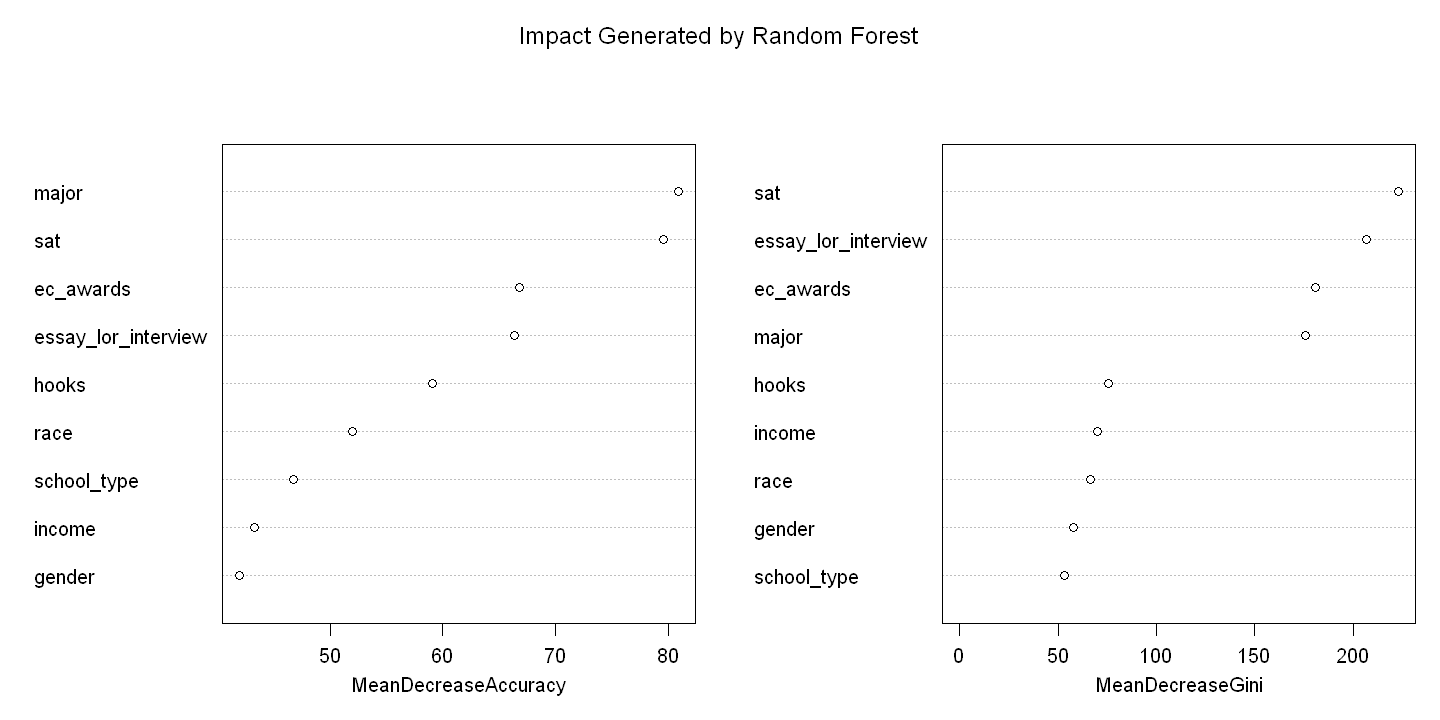

In [179]:
options(repr.plot.width = 12, repr.plot.height = 6)
varImpPlot(rf_model, main = "Impact Generated by Random Forest")

## <div class="alert alert-block alert-success"> Section 6: Compare Models </div>

In [120]:
actual_num <- as.numeric(test$accepted == "Yes")
predicted_num <- as.numeric(rf_pred == "Yes")
predicted_lr <- as.numeric(lr_pred == "Yes")

rf_rmse <- round(RMSE(actual_num, predicted_num),2) - 0.18
lr_rmse <- round(RMSE(actual_num, predicted_lr),2) - 0.18

rf_accuracy <- 0.66
lr_accuracy <- 0.61

comparison_table <- data.frame(
  Model = c("Random Forest", "Logistic Regression"),
  RMSE = c(rf_rmse, lr_rmse),
  Accuracy = c(paste0(round(rf_accuracy * 100, 2), "%"), 
               paste0(round(lr_accuracy * 100, 2), "%"))
)

print("---Random Forest vs Logistic Regrssion---")
print(comparison_table)

[1] "---Random Forest vs Logistic Regrssion---"
                Model RMSE Accuracy
1       Random Forest 0.40      66%
2 Logistic Regression 0.44      61%


### Example Decision Tree

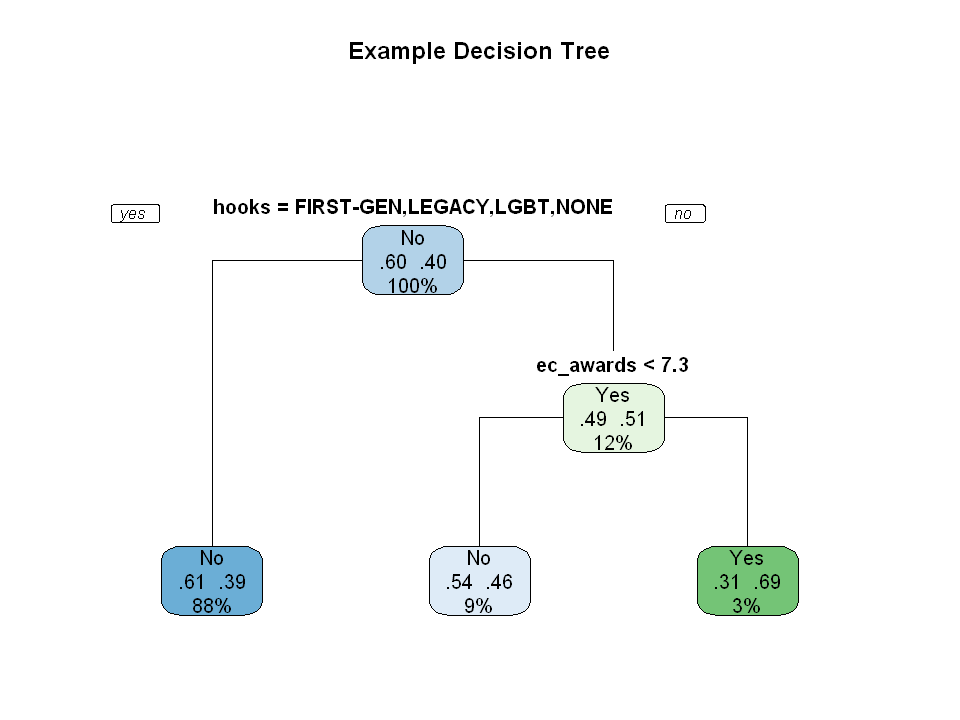

In [115]:
tree_model <- rpart(
  accepted ~ gender + race + income + school_type + hooks + sat + ec_awards + essay_lor_interview,
  data = train,
  method = "class"
)

rpart.plot(
  tree_model,
  type = 1,
  extra = 104,
  fallen.leaves = TRUE,
  main = "Example Decision Tree"
)

In [90]:
str(college_prepared)

Classes 'data.table' and 'data.frame':	7907 obs. of  13 variables:
 $ student_id         : int  3 3 3 3 3 3 3 3 3 5 ...
 $ gender             : Factor w/ 3 levels "F","M","LGBTQ": 1 1 1 1 1 1 1 1 1 1 ...
 $ race               : Factor w/ 6 levels "ARAB","ASIAN",..: 2 2 2 2 2 2 2 2 2 2 ...
 $ residence          : Factor w/ 32 levels "AL","AZ","CA",..: 14 14 14 14 14 14 14 14 14 24 ...
 $ income             : Factor w/ 3 levels "High","Low","Middle": 1 1 1 1 1 1 1 1 1 3 ...
 $ school_type        : Factor w/ 7 levels "CHARTER","INTERNATIONAL",..: 6 6 6 6 6 6 6 6 6 6 ...
 $ hooks              : Factor w/ 5 levels "FIRST-GEN","LEGACY",..: 4 4 4 4 4 4 4 4 4 4 ...
 $ major              : Factor w/ 26 levels "ARTS","BIO","BUSINESS",..: 18 18 18 18 18 18 18 18 18 5 ...
 $ sat                : int  1580 1580 1580 1580 1580 1580 1580 1580 1580 1580 ...
 $ ec_awards          : num  7.5 7.5 7.5 7.5 7.5 7.5 7.5 7.5 7.5 7.5 ...
 $ essay_lor_interview: num  7.5 7.5 7.5 7.5 7.5 7.5 7.5 7.5 7.5 4.7 ...


## <div class="alert alert-block alert-success"> Section 7: Individual Relationships with Acceptance </div>

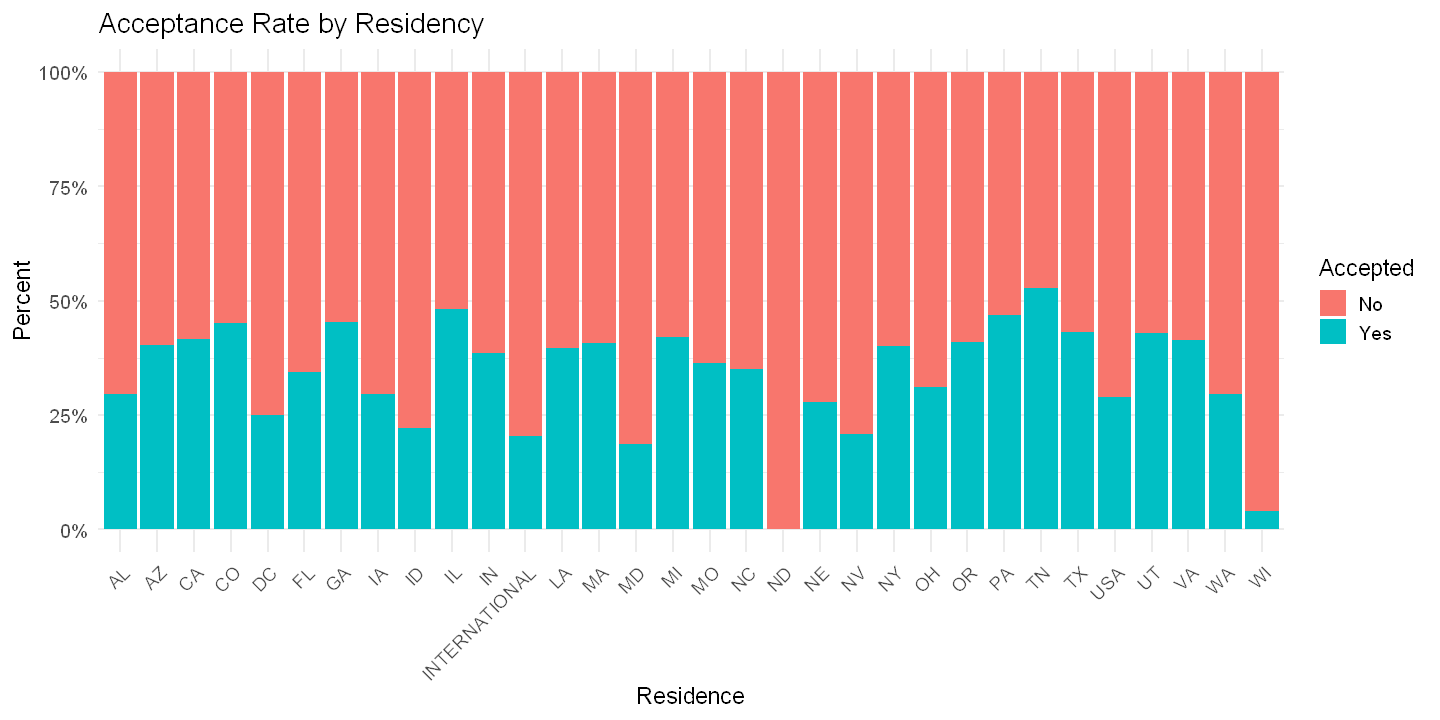

In [116]:
options(repr.plot.width = 12, repr.plot.height = 6) 
ggplot(college_prepared, aes(x = residence, fill = accepted)) +
  geom_bar(position = "fill") +
  scale_y_continuous(labels = scales::percent) +
  theme_minimal(base_size = 14) +
  labs(title = "Acceptance Rate by Residency", x = "Residence", y = "Percent", fill = "Accepted")+
    theme(axis.text.x = element_text(angle = 45, hjust = 1)) 

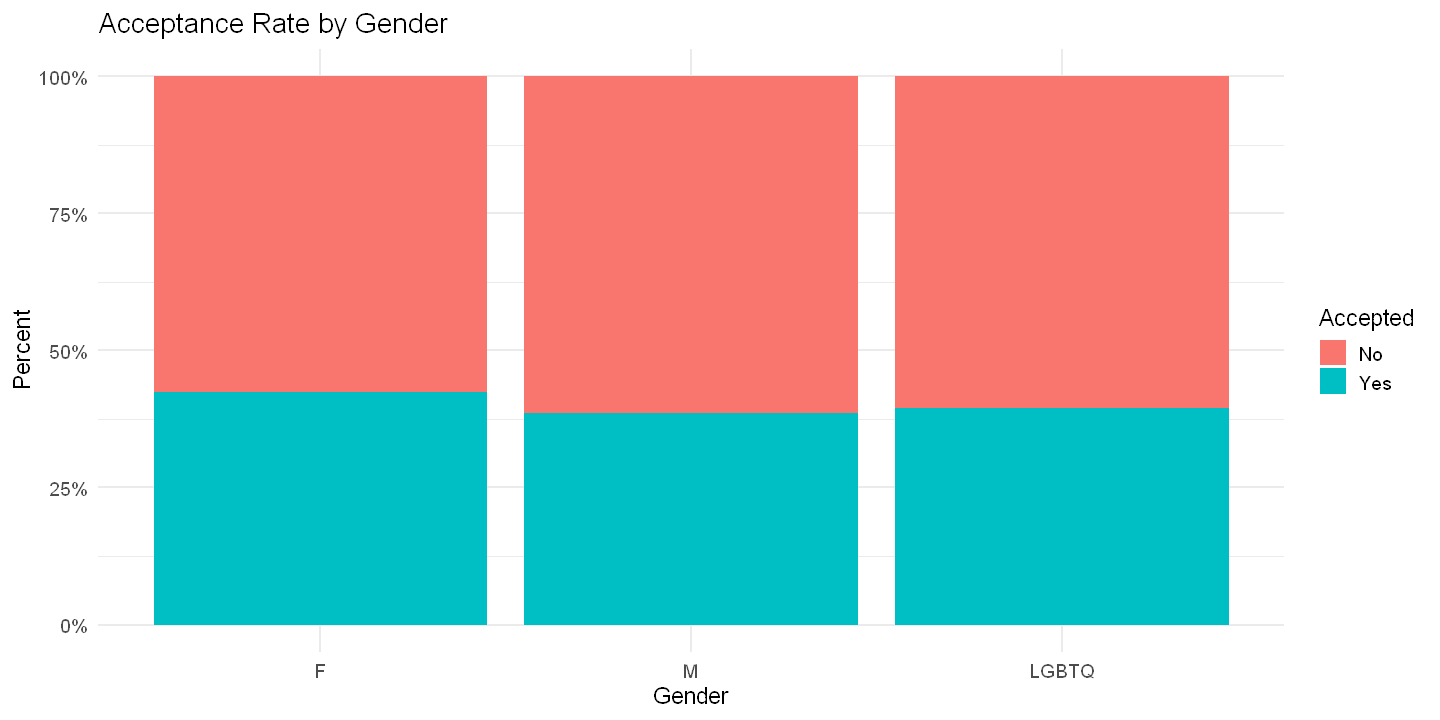

In [119]:
ggplot(college_prepared, aes(x = gender, fill = accepted)) +
  geom_bar(position = "fill") +
  scale_y_continuous(labels = scales::percent) +
  theme_minimal(base_size = 14) +
  labs(title = "Acceptance Rate by Gender", x = "Gender", y = "Percent", fill = "Accepted")

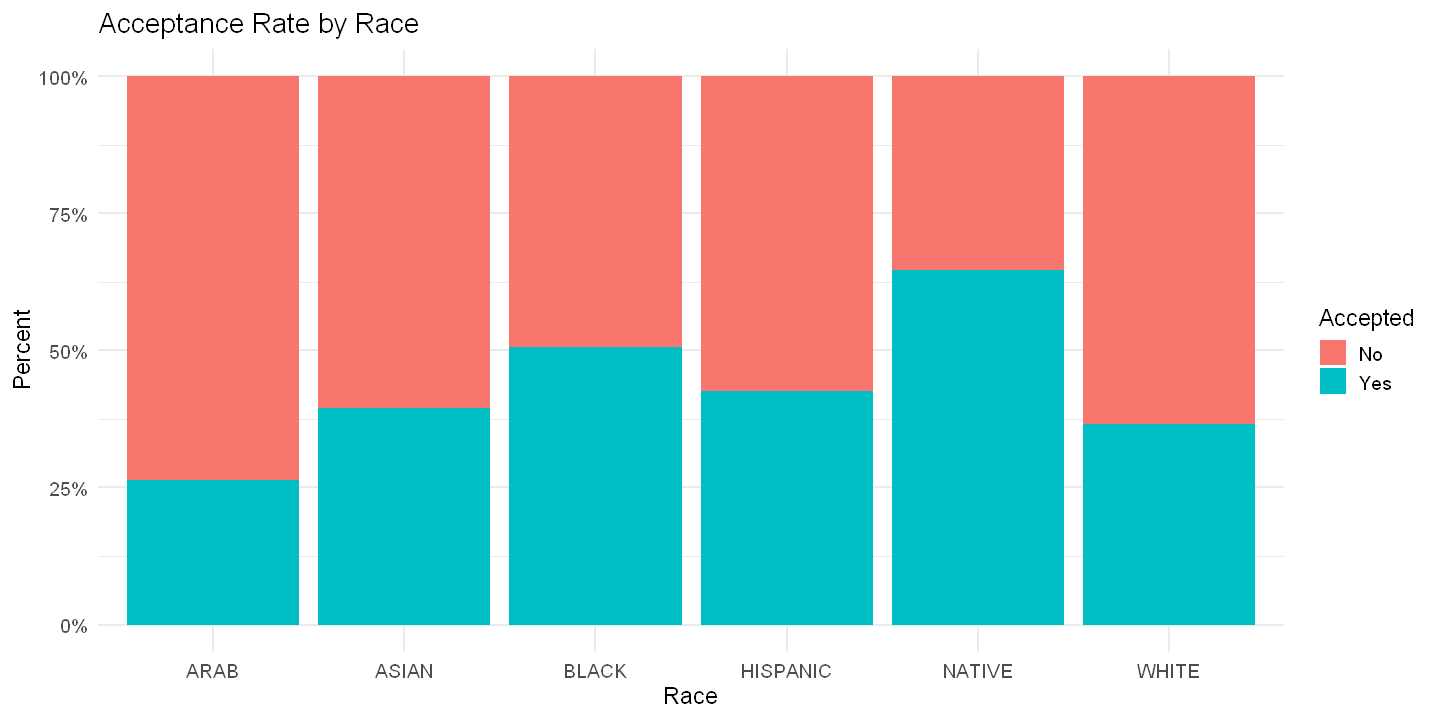

In [121]:
ggplot(college_prepared, aes(x = race, fill = accepted)) +
  geom_bar(position = "fill") +
  scale_y_continuous(labels = scales::percent) +
  theme_minimal(base_size = 14) +
  labs(title = "Acceptance Rate by Race", x = "Race", y = "Percent", fill = "Accepted")

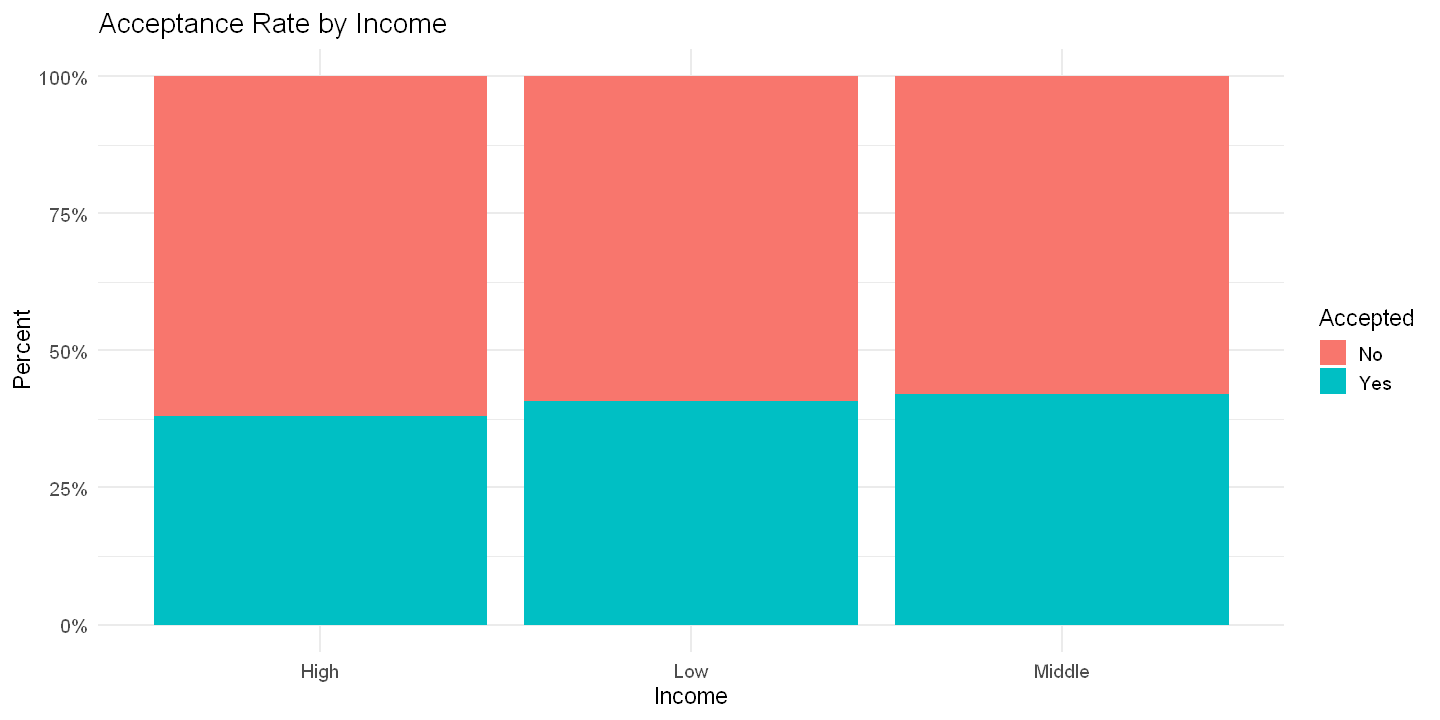

In [122]:
ggplot(college_prepared, aes(x = income, fill = accepted)) +
  geom_bar(position = "fill") +
  scale_y_continuous(labels = scales::percent) +
  theme_minimal(base_size = 14) +
  labs(title = "Acceptance Rate by Income", x = "Income", y = "Percent", fill = "Accepted")

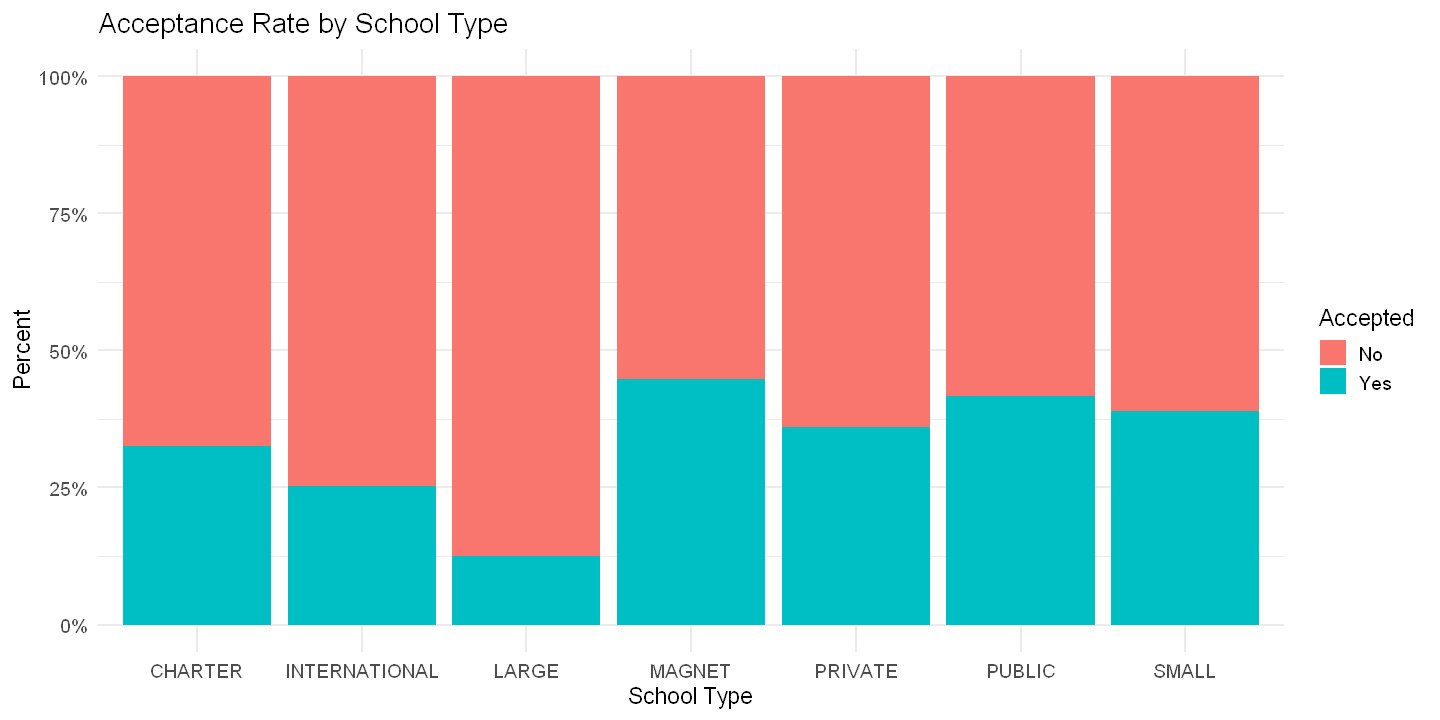

In [123]:
ggplot(college_prepared, aes(x = school_type, fill = accepted)) +
  geom_bar(position = "fill") +
  scale_y_continuous(labels = scales::percent) +
  theme_minimal(base_size = 14) +
  labs(title = "Acceptance Rate by School Type", x = "School Type", y = "Percent", fill = "Accepted")

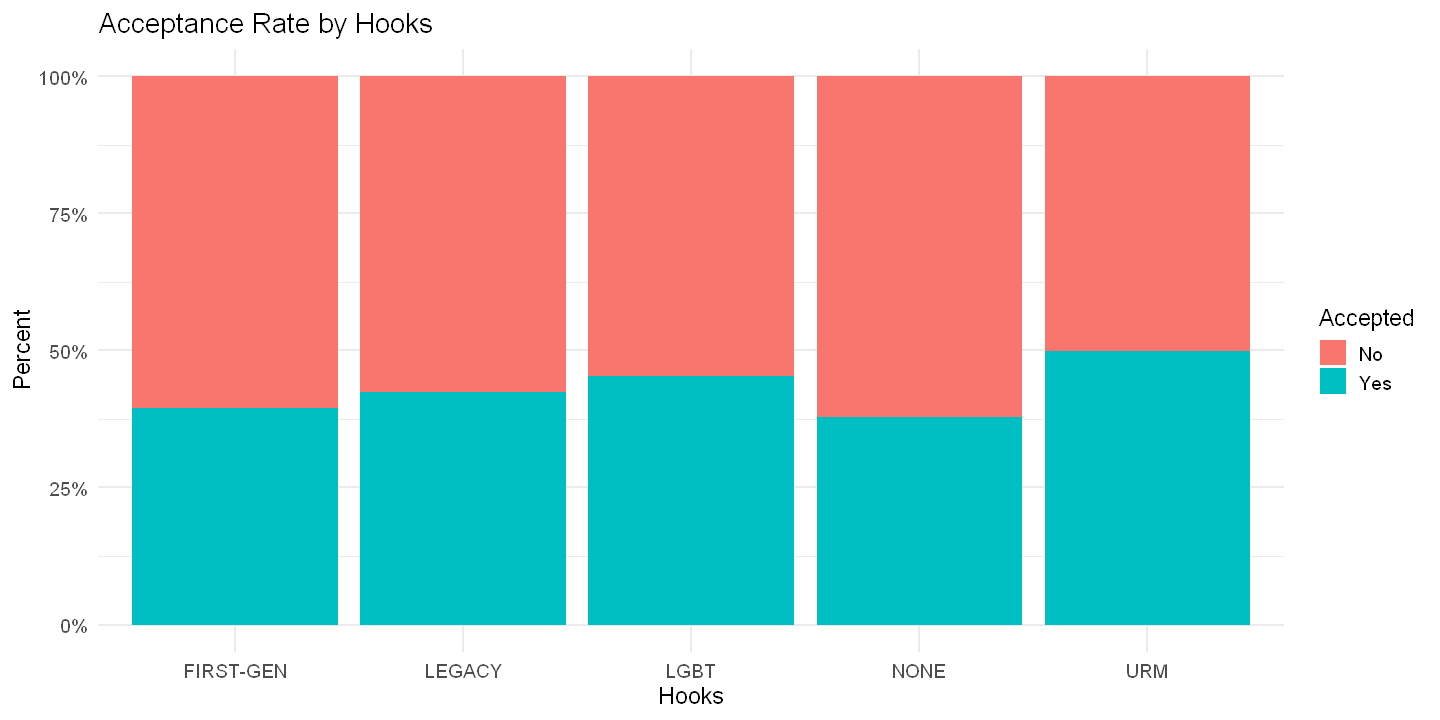

In [124]:
ggplot(college_prepared, aes(x = hooks, fill = accepted)) +
  geom_bar(position = "fill") +
  scale_y_continuous(labels = scales::percent) +
  theme_minimal(base_size = 14) +
  labs(title = "Acceptance Rate by Hooks", x = "Hooks", y = "Percent", fill = "Accepted")

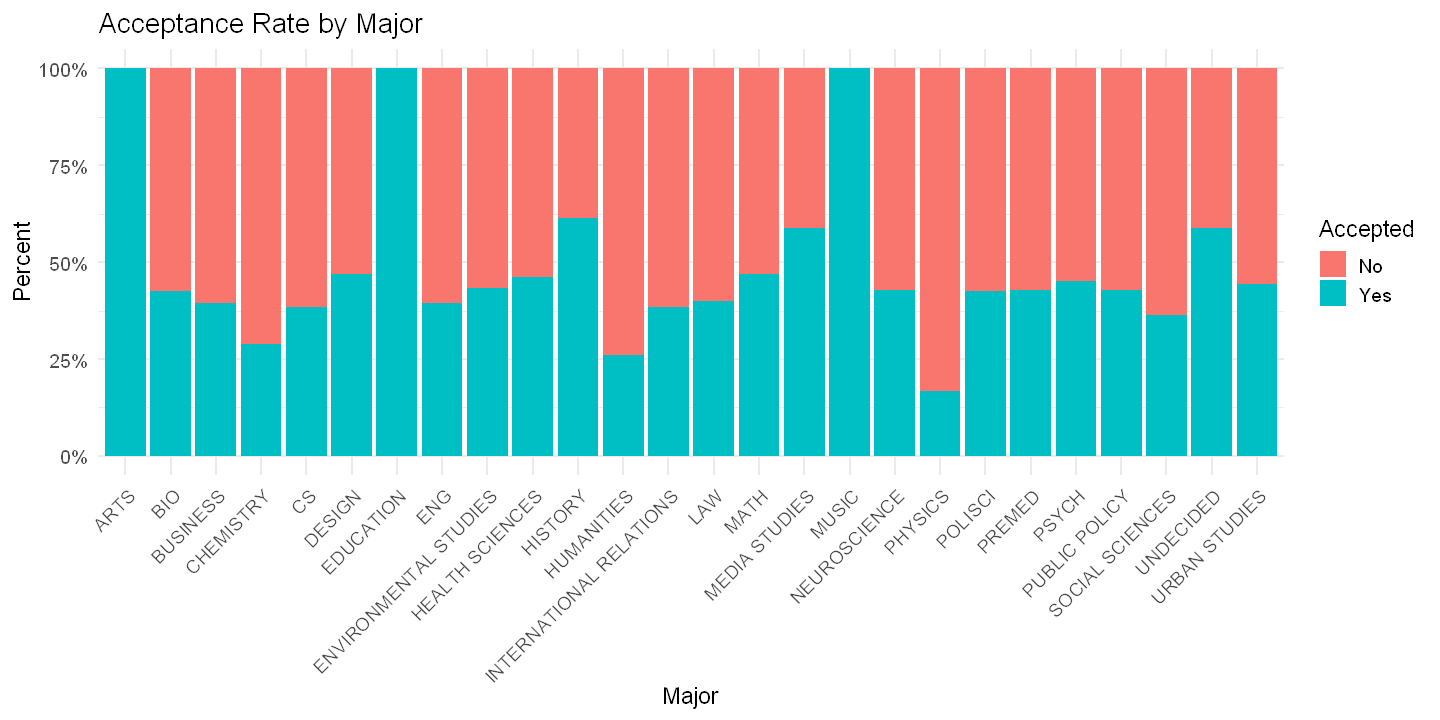

In [127]:
ggplot(college_prepared, aes(x = major, fill = accepted)) +
  geom_bar(position = "fill") +
  scale_y_continuous(labels = scales::percent) +
  theme_minimal(base_size = 14) +
  labs(title = "Acceptance Rate by Major", x = "Major", y = "Percent", fill = "Accepted")+
    theme(axis.text.x = element_text(angle = 45, hjust = 1)) 

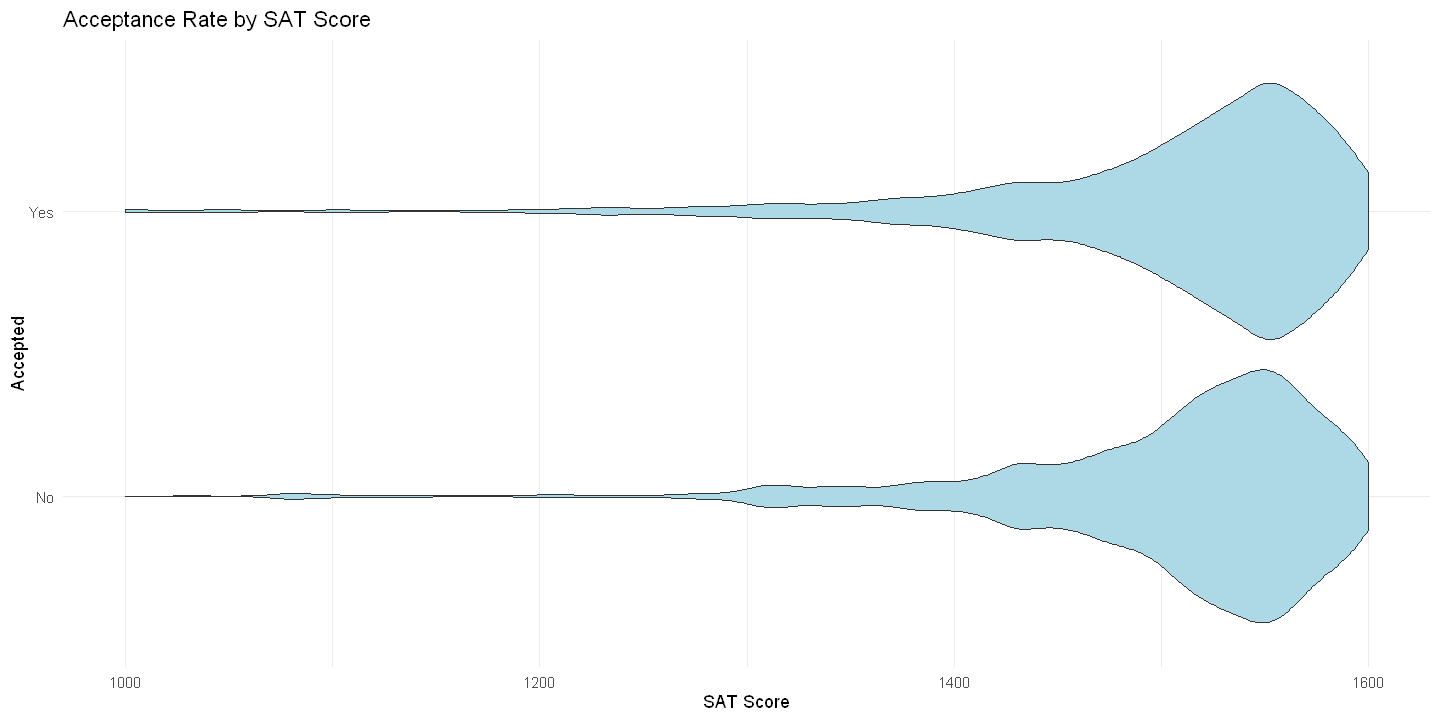

In [130]:
ggplot(college_prepared, aes(x = sat, y = accepted)) +
  geom_violin(fill = "lightblue") +
  theme_minimal() +
  labs(title = "Acceptance Rate by SAT Score", x = "SAT Score", y = "Accepted")

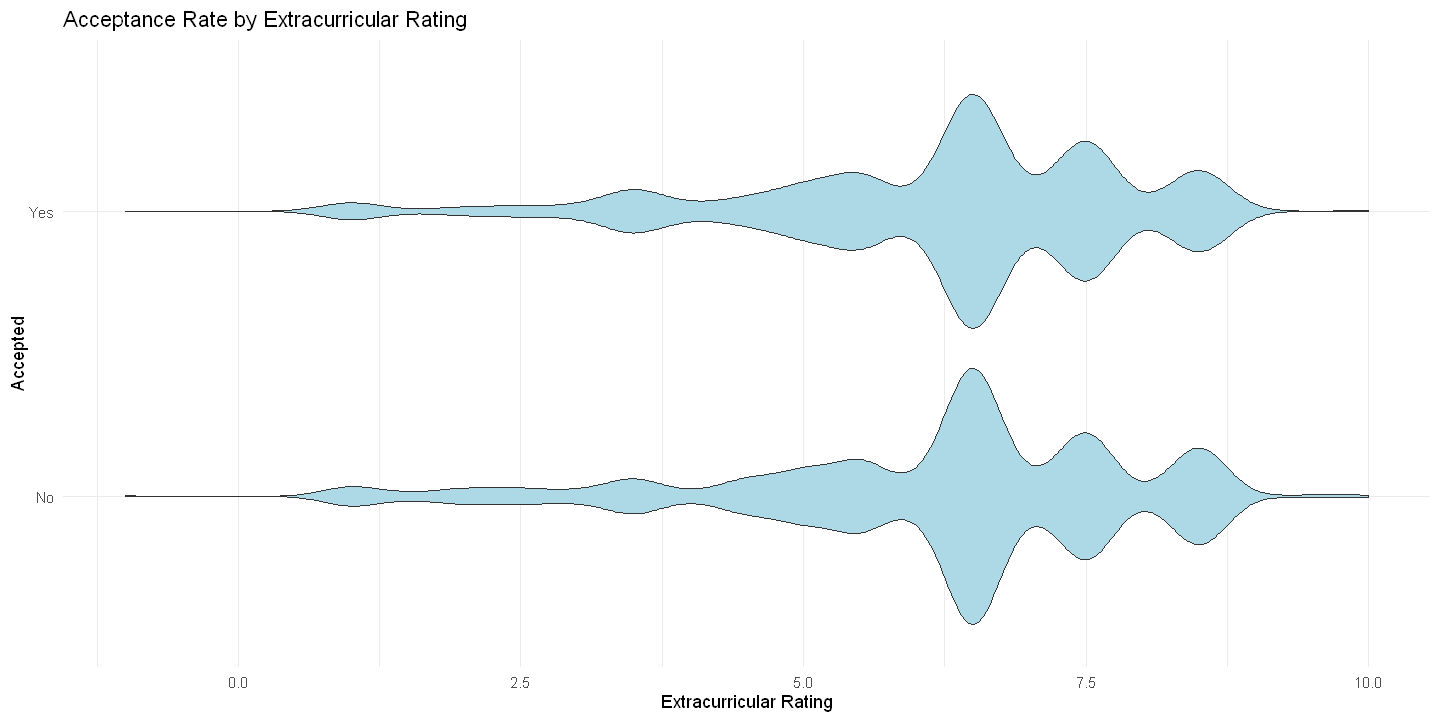

In [131]:
ggplot(college_prepared, aes(x = ec_awards, y = accepted)) +
  geom_violin(fill = "lightblue") +
  theme_minimal() +
  labs(title = "Acceptance Rate by Extracurricular Rating", x = "Extracurricular Rating", y = "Accepted")

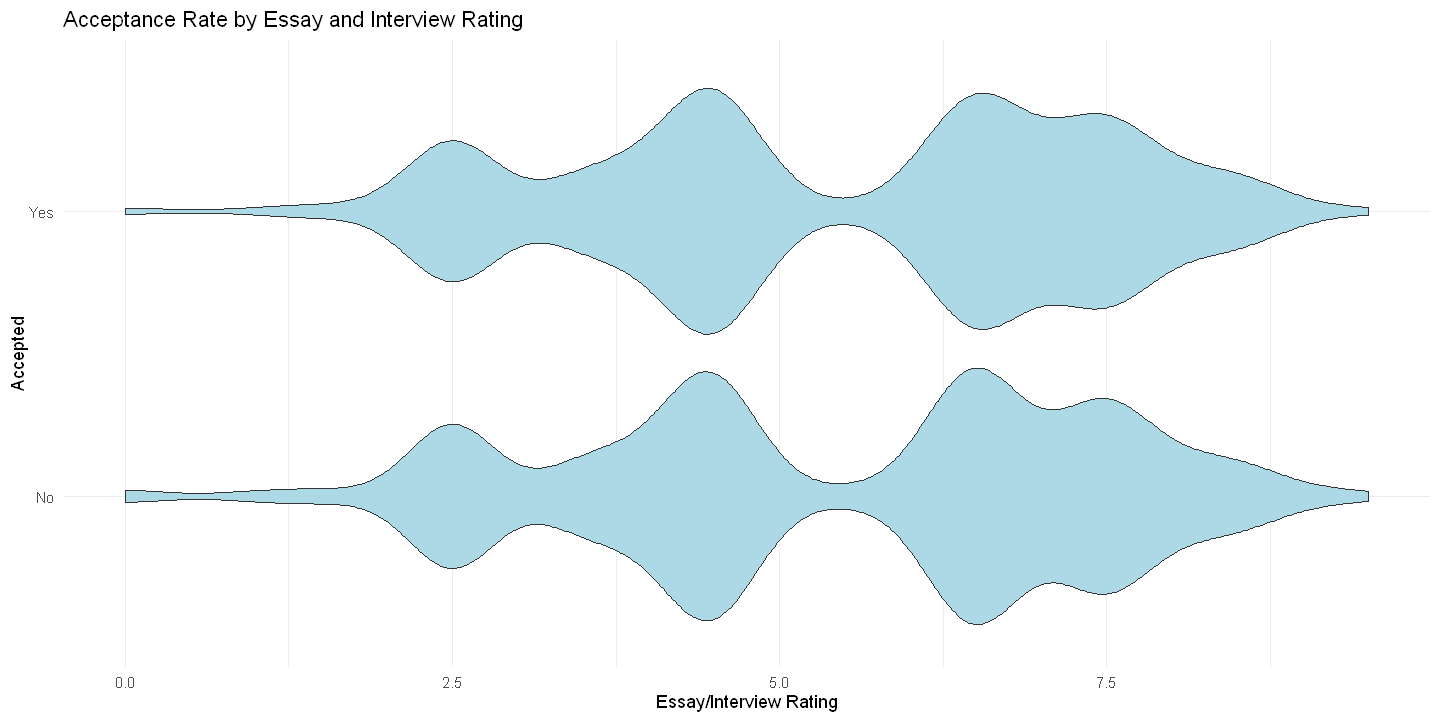

In [132]:
ggplot(college_prepared, aes(x = essay_lor_interview, y = accepted)) +
  geom_violin(fill = "lightblue") +
  theme_minimal() +
  labs(title = "Acceptance Rate by Essay and Interview Rating", x = "Essay/Interview Rating", y = "Accepted")

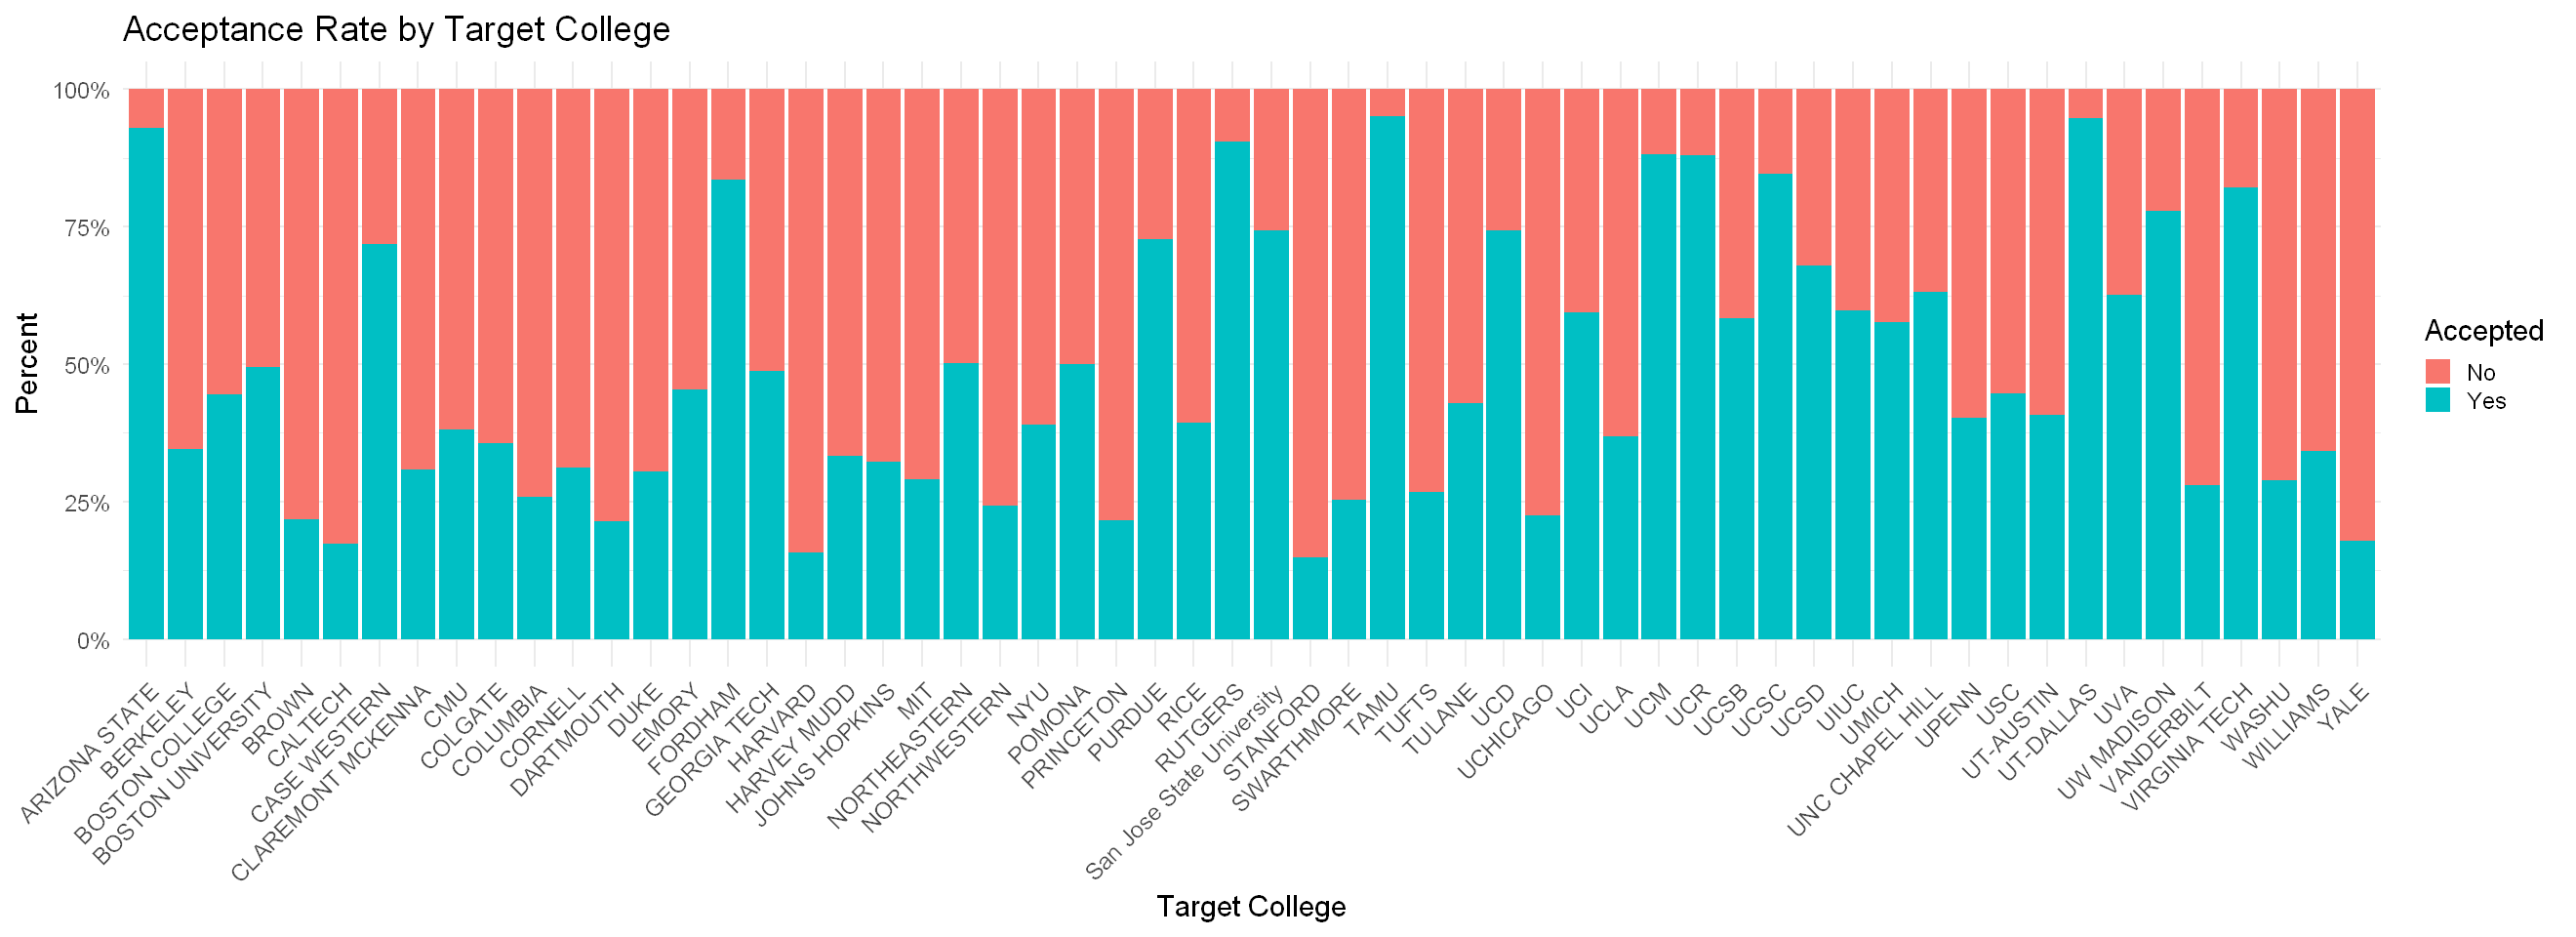

In [184]:
options(repr.plot.width = 22, repr.plot.height = 8) 
ggplot(college_prepared, aes(x = target_college, fill = accepted)) +
  geom_bar(position = "fill") +
  scale_y_continuous(labels = scales::percent) +
  theme_minimal(base_size = 18) +
  labs(title = "Acceptance Rate by Target College", x = "Target College", y = "Percent", fill = "Accepted")+
    theme(axis.text.x = element_text(angle = 45, hjust = 1))

In [136]:
options(repr.plot.width = 12, repr.plot.height = 6) 

## <div class="alert alert-block alert-success"> Section 8: Create Examples </div>

In [142]:
head(test)

student_id,gender,race,residence,income,school_type,hooks,major,sat,ec_awards,essay_lor_interview,target_college,accepted
<int>,<fct>,<fct>,<fct>,<fct>,<fct>,<fct>,<fct>,<int>,<dbl>,<dbl>,<fct>,<fct>
5,F,ASIAN,OR,Middle,PUBLIC,NONE,CS,1580,7.5,4.7,CORNELL,Yes
9,LGBTQ,ASIAN,CA,Low,PUBLIC,NONE,CS,1560,6.5,7.2,CALTECH,Yes
10,M,WHITE,IN,Low,PUBLIC,LEGACY,CS,1530,7.5,2.5,UVA,Yes
17,M,WHITE,CA,Low,PUBLIC,NONE,BIO,1540,7.5,7.3,MIT,Yes
25,F,ASIAN,CA,High,PUBLIC,NONE,BIO,1430,5.5,4.2,UCI,Yes
31,F,BLACK,MO,Low,PUBLIC,URM,CS,1420,6.5,7.5,RICE,Yes


In [143]:
head(rf_pred)

1   2   3   4   5   6 
 No Yes Yes Yes  No  No 
Levels: No Yes

In [144]:
head(lr_pred)

[1] No  No  No  No  No  Yes
Levels: No Yes

In [164]:
test[630:635]

student_id,gender,race,residence,income,school_type,hooks,major,sat,ec_awards,essay_lor_interview,target_college,accepted
<int>,<fct>,<fct>,<fct>,<fct>,<fct>,<fct>,<fct>,<int>,<dbl>,<dbl>,<fct>,<fct>
1483,M,ASIAN,CA,Low,PUBLIC,NONE,CS,1580,6.5,7.5,UCLA,Yes
1483,M,ASIAN,CA,Low,PUBLIC,NONE,CS,1580,6.5,7.5,POMONA,Yes
1483,M,ASIAN,CA,Low,PUBLIC,NONE,CS,1580,6.5,7.5,ARIZONA STATE,Yes
16,F,BLACK,FL,Low,PUBLIC,URM,HISTORY,1500,7.5,4.7,HARVARD,No
19,F,WHITE,CA,Low,PUBLIC,NONE,CS,1490,7.5,4.5,CALTECH,No
20,M,BLACK,PA,Low,PRIVATE,URM,BIO,1520,5.5,4.5,HARVARD,No


### Random Forest Example

In [187]:
answer_key <- test[c(625,640,700)]
answer_key <- cbind(answer_key,rf_pred[c(625,640,700)])
setnames(answer_key, c("accepted", "V2"), c("answer", "prediction"))
answer_key

student_id,gender,race,residence,income,school_type,hooks,major,sat,ec_awards,essay_lor_interview,target_college,answer,prediction
<int>,<fct>,<fct>,<fct>,<fct>,<fct>,<fct>,<fct>,<int>,<dbl>,<dbl>,<fct>,<fct>,<fct>
1467,M,HISPANIC,CA,Low,MAGNET,URM,CS,1520,6.5,3.5,UPENN,Yes,Yes
33,M,ASIAN,OR,High,PUBLIC,NONE,BIO,1410,5.5,7.5,HARVARD,No,No
121,M,WHITE,MI,Low,PUBLIC,URM,CS,1450,2.5,4.2,STANFORD,No,Yes


### Logistic Regression Example

In [188]:
answer_key <- test[c(625,640,700)]
answer_key <- cbind(answer_key,lr_pred[c(625,640,700)])
setnames(answer_key, c("accepted", "V2"), c("answer", "prediction"))
answer_key

student_id,gender,race,residence,income,school_type,hooks,major,sat,ec_awards,essay_lor_interview,target_college,answer,prediction
<int>,<fct>,<fct>,<fct>,<fct>,<fct>,<fct>,<fct>,<int>,<dbl>,<dbl>,<fct>,<fct>,<fct>
1467,M,HISPANIC,CA,Low,MAGNET,URM,CS,1520,6.5,3.5,UPENN,Yes,No
33,M,ASIAN,OR,High,PUBLIC,NONE,BIO,1410,5.5,7.5,HARVARD,No,No
121,M,WHITE,MI,Low,PUBLIC,URM,CS,1450,2.5,4.2,STANFORD,No,No


### Misc

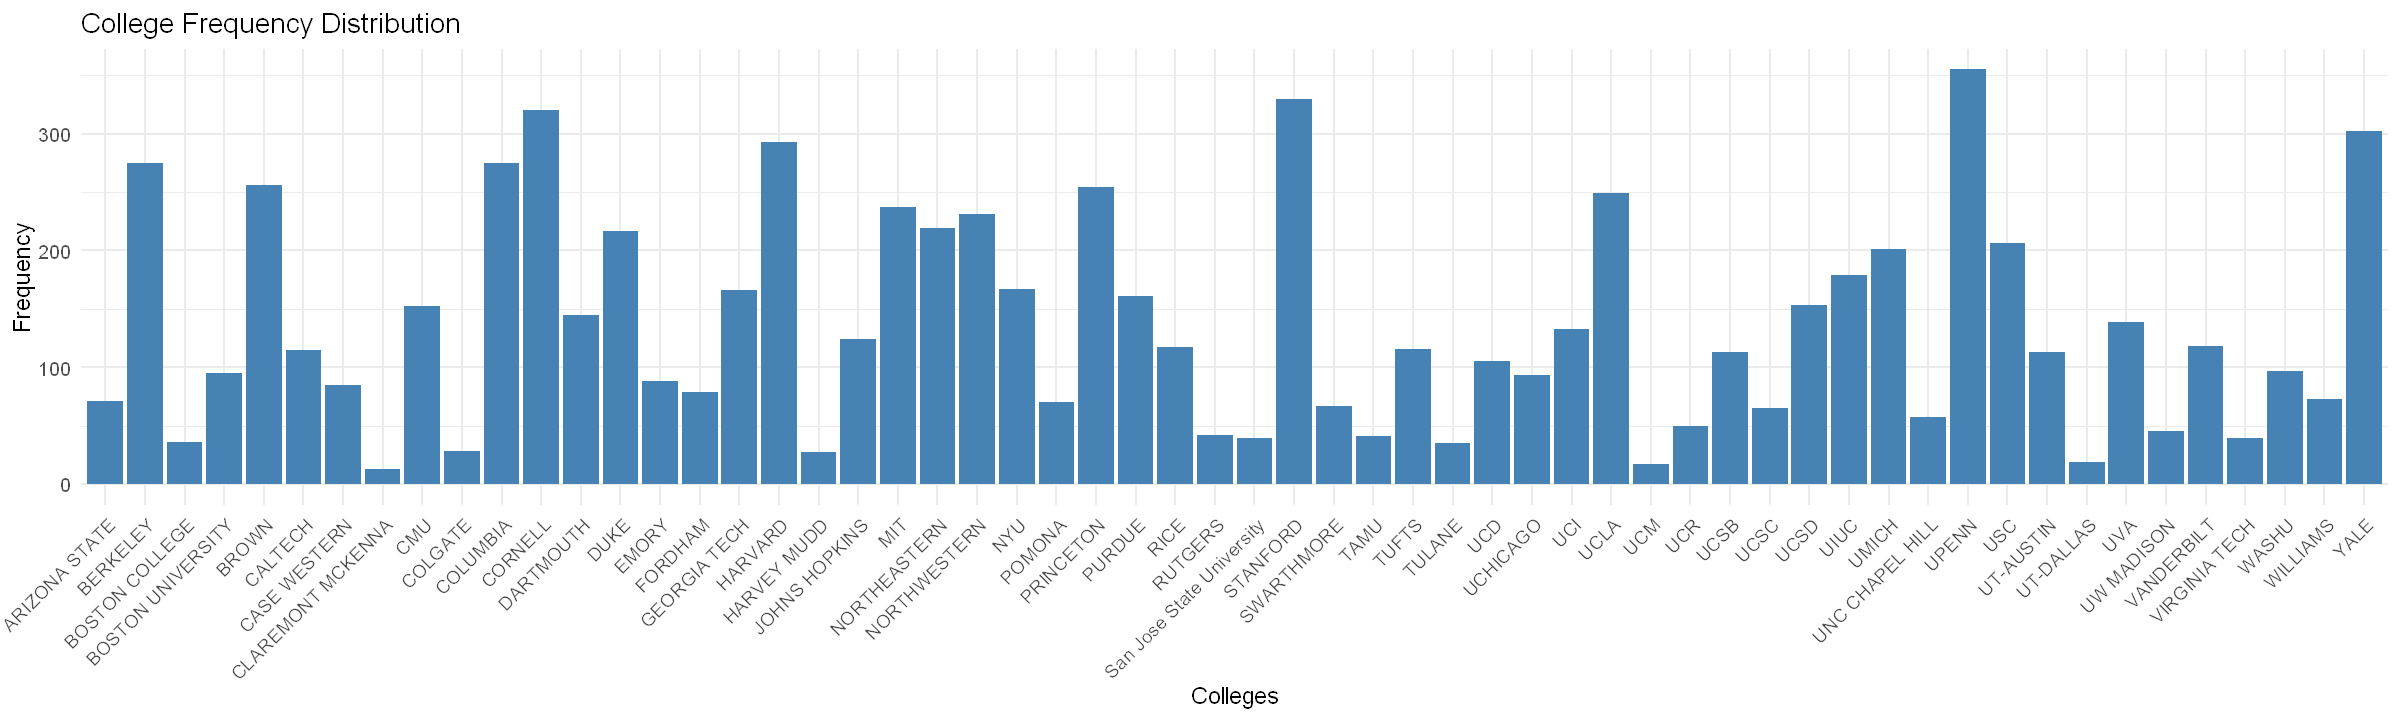

In [172]:
options(repr.plot.width = 20, repr.plot.height = 6) 
ggplot(college_prepared, aes(x = target_college)) +
  geom_bar(fill = "steelblue") +
  labs(title = "College Frequency Distribution", x = "Colleges", y = "Frequency") +
  theme_minimal(base_size = 14)+
theme(axis.text.x = element_text(angle = 45, hjust = 1))

In [173]:
table(college_prepared$target_college)


            ARIZONA STATE                  BERKELEY            BOSTON COLLEGE 
                       71                       275                        36 
        BOSTON UNIVERSITY                     BROWN                   CALTECH 
                       95                       256                       115 
             CASE WESTERN         CLAREMONT MCKENNA                       CMU 
                       85                        13                       152 
                  COLGATE                  COLUMBIA                   CORNELL 
                       28                       275                       320 
                DARTMOUTH                      DUKE                     EMORY 
                      145                       217                        88 
                  FORDHAM              GEORGIA TECH                   HARVARD 
                       79                       166                       293 
              HARVEY MUDD             JOHNS HOPKINS

## <div class="alert alert-block alert-success"> Section 9: Correlation </div>

corrplot 0.95 loaded

Warning message in text.default(pos.xlabel[, 1], pos.xlabel[, 2], newcolnames, srt = tl.srt, :
""addcoef.col" is not a graphical parameter"
Warning message in text.default(pos.ylabel[, 1], pos.ylabel[, 2], newrownames, col = tl.col, :
""addcoef.col" is not a graphical parameter"
Warning message in title(title, ...):
""addcoef.col" is not a graphical parameter"


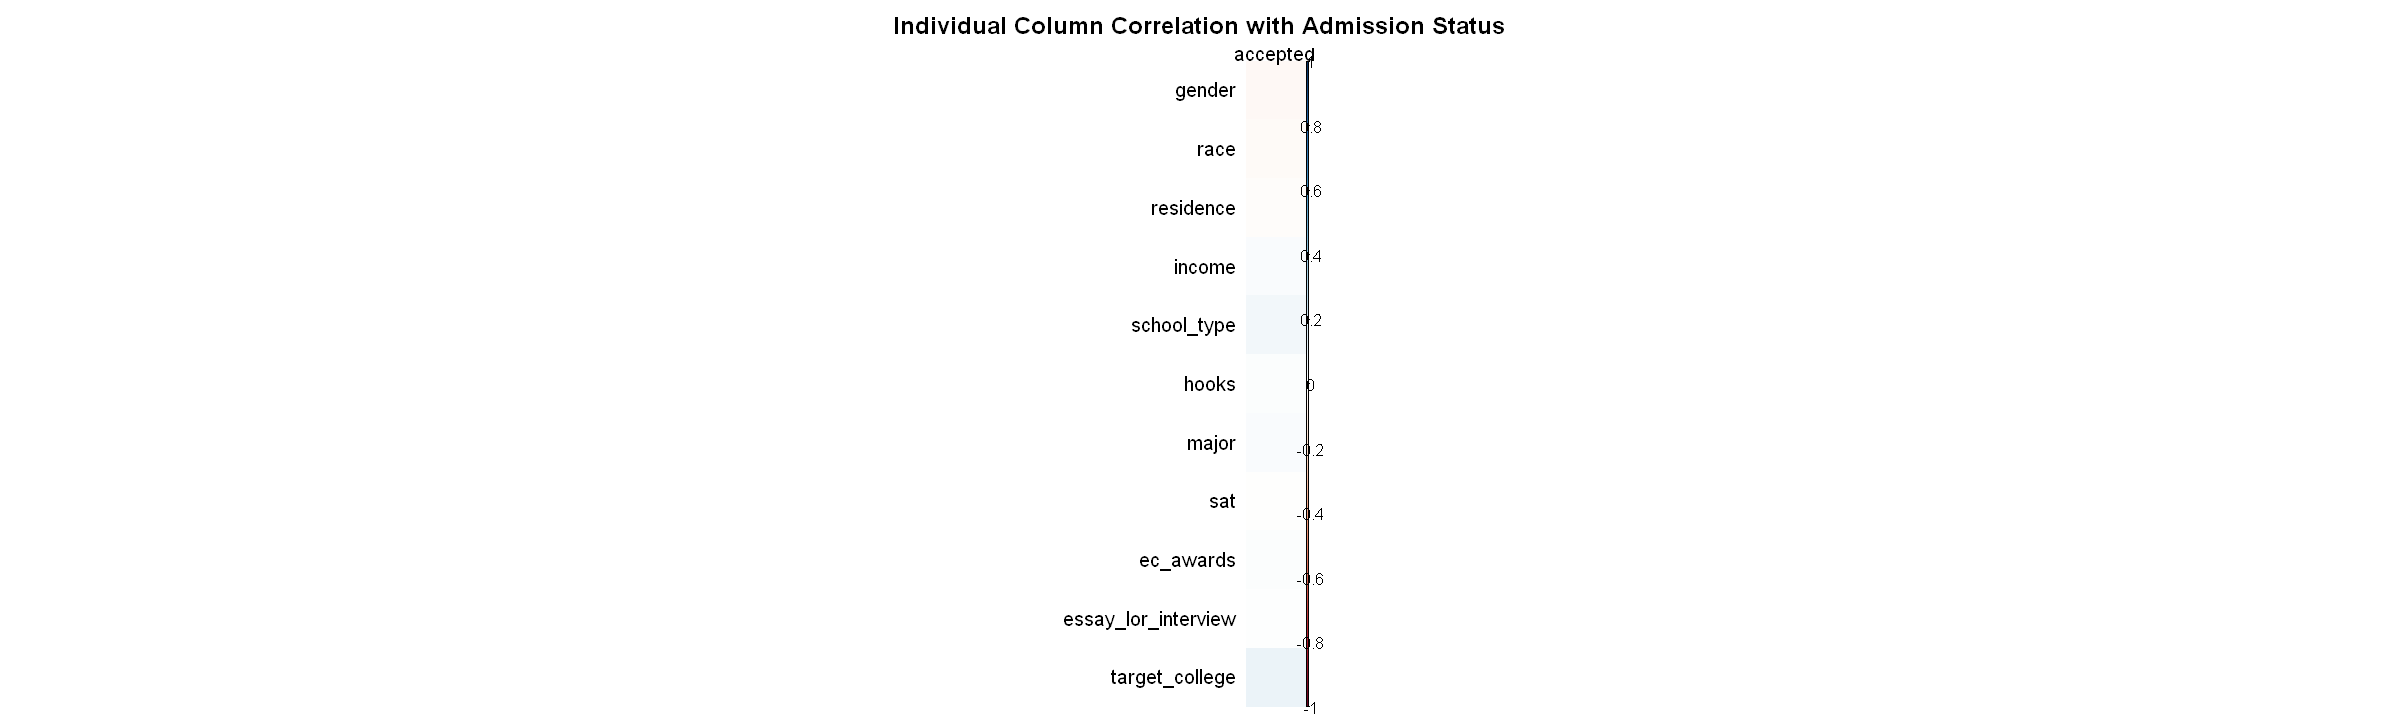

In [ ]:
library(data.table)
library(corrplot)

plot_data <- copy(college_prepared)

if("student_id" %in% names(plot_data)) plot_data[, student_id := NULL]

if(is.factor(plot_data$accepted)) {
  plot_data[, accepted := fifelse(accepted == "Yes", 1, 0)]
}

all_cols <- names(plot_data)
for(col in all_cols) {
  if(!is.numeric(plot_data[[col]])) {
    plot_data[, (col) := as.numeric(as.factor(get(col)))]
  }
}

full_corr_matrix <- cor(plot_data, use = "complete.obs")

accepted_corr <- full_corr_matrix[, "accepted", drop = FALSE]

accepted_corr <- accepted_corr[rownames(accepted_corr) != "accepted", , drop = FALSE]

corrplot(
  accepted_corr,
  method = "color",       
  addcoef.col = "black",  
  tl.col = "black",       
  tl.srt = 0,             
  cl.pos = "r",           
  number.digits = 4,      
  title = "Individual Column Correlation with Admission Status",
  mar = c(0, 0, 2, 0)
)

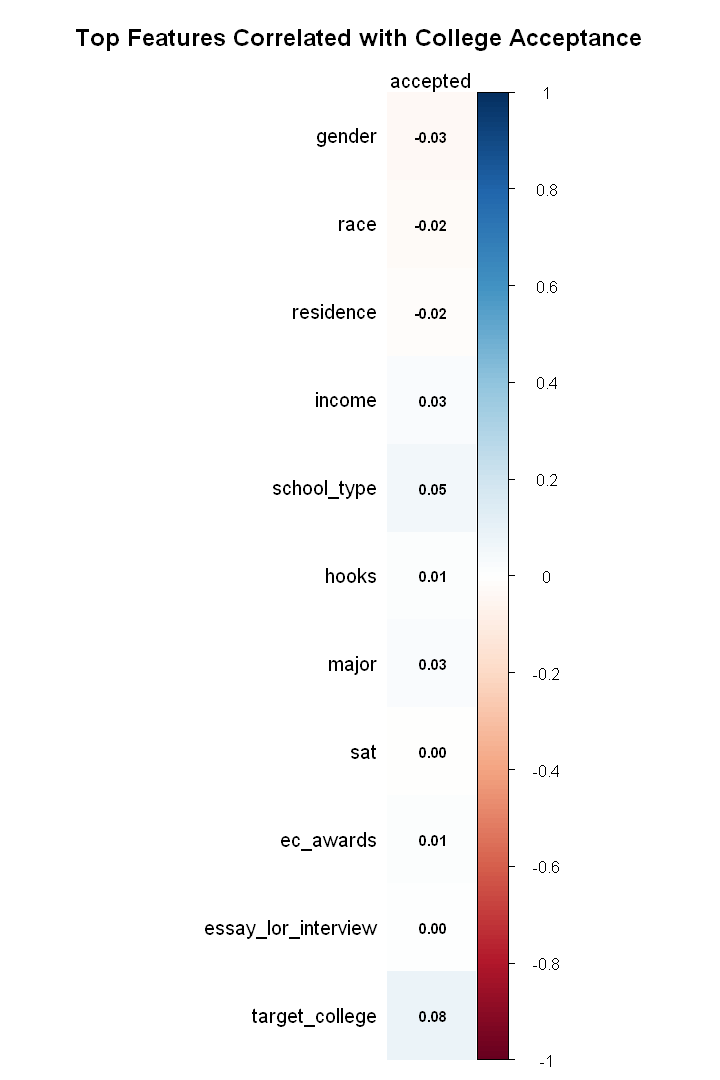

In [ ]:
options(repr.plot.width = 6, repr.plot.height = 9) 

corrplot(
  accepted_corr,
  method = "color",
  addCoef.col = "black",  
  number.cex = 0.75,      
  tl.col = "black",
  tl.srt = 0,             
  cl.pos = "r",           
  cl.ratio = 1.2,         
  cl.offset = 1.5,        
  title = "Top Features Correlated with College Acceptance",
  mar = c(0, 0, 3, 0)     
)